# Band-power comparison of SD and NS

Bad channels are interpolated

## PRE PROCESSING

In [1]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
%matplotlib inline

In [2]:
# lists to collect data
X_list = []
y_list = []
data_NS_list =[]
data_SD_list =[]

In [ ]:
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i== 39 or i== 43:
        continue  # Skip participant 1,28 due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:\\BCI\\TASKS\\Task-8\\ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:\\BCI\\TASKS\\Task-8\\processed_epochs\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs
        
        
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average', projection=True)
            eeg_raw.apply_proj()
            
            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=4.0, overlap=0.0,preload=True)
            
            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            raw.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            raw.interpolate_bads(reset_bads=True)

            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)        

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})
        
        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        #if (i == 39 or i == 43) and j == 2:
        #    data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.

        epoch_labels = labels['label'].values  
        
        if i <= 71:  
            X_list.append(data)
            y_list.append(epoch_labels)

        if j==1:
            data_NS_list.append(data)
        elif j==2:
            data_SD_list.append(data)

# After the loop, concatenate into arrays
X= np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
data_SD = np.concatenate(data_SD_list, axis=0)
data_NS = np.concatenate(data_NS_list, axis=0)


Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif ...


C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\2151765031.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\2151765031.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task

C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\2151765031.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\2151765031.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-03_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-04_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-04_ses-1_epochs.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
75 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-04_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task

...

Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-1_epochs.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\2151765031.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 61) active
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\2151765031.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs\sub-71_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
75 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated


In [4]:
print(X.shape)
print(y.shape)
print(data_SD.shape)
print(data_NS.shape)
print(X)
print(y)

(9852, 61, 2000)
(9852,)
(4915, 61, 2000)
(4937, 61, 2000)
[[[-7.92730533e-21 -1.57691204e-06 -3.05410050e-06 ... -1.34819336e-05
   -1.24793797e-05 -1.17790212e-05]
  [-3.02679220e-22 -5.19617274e-08 -2.59382455e-07 ... -1.53334751e-05
   -1.49304371e-05 -1.45435180e-05]
  [-6.20186957e-21  8.35625527e-07  1.18303895e-06 ...  3.90105352e-07
   -3.31034361e-07 -4.02590561e-06]
  ...
  [-7.08630707e-21  1.12053179e-06  2.37601327e-06 ...  1.31918506e-05
    1.30800113e-05  1.29405784e-05]
  [-2.84700967e-21  3.48294376e-07  9.48654293e-07 ...  8.88237950e-06
    9.65283961e-06  1.08367633e-05]
  [ 3.51565850e-21  1.92671191e-06  3.82841324e-06 ...  1.16042146e-05
    1.02647695e-05  8.66637417e-06]]

 [[-1.14525871e-05 -1.14853820e-05 -1.17844094e-05 ... -1.03054249e-06
    5.47694804e-07  1.84719525e-06]
  [-1.42129059e-05 -1.39575452e-05 -1.37835454e-05 ...  1.36744057e-06
    2.80684256e-06  3.97822234e-06]
  [-9.82245827e-06 -1.63923549e-05 -2.22485122e-05 ...  1.06129491e-06
    3.

In [5]:
min_length = min(len(data_NS), len(data_SD))
print("Minimum length for balancing:", min_length)
def balance_data(data_array, target_length):
    # If this is the larger array, sample it down
    if len(data_array) > target_length:
        # random_state=42 ensures you get the same 'random' choice every time (reproducible)
        indices = np.random.choice(len(data_array), target_length, replace=False)
        return data_array[indices]
    return data_array

Minimum length for balancing: 4915


In [6]:
data_NS = balance_data(data_NS, min_length)
data_SD = balance_data(data_SD, min_length)
print("Balanced data_NS shape:", data_NS.shape)
print("Balanced data_SD shape:", data_SD.shape)

Balanced data_NS shape: (4915, 61, 2000)
Balanced data_SD shape: (4915, 61, 2000)


In [ ]:
#no of epoches obtained
n_epochs = data_NS.shape[0] + data_SD.shape[0]
print("Total number of epochs:", n_epochs)

Total number of epochs: 9830


## Band Power Extraction

In [8]:
def get_bandpower_batched(data, fs, band_range, batch_size=200):
 
    results = []
    n_epochs = data.shape[0]
    
    # Internal Loop: Handles the batching for you
    for i in range(0, n_epochs, batch_size):
        batch_data = data[i : i + batch_size,:,:]
        
        # 1. Welch (Frequency Domain)
        freqs, psd = signal.welch(batch_data, fs=fs, axis=-1)
        
        # 2. Band Mask
        mask = (freqs >= band_range[0]) & (freqs <= band_range[1])
        
        # 3. Integrate
        power_channels = np.trapezoid(psd[..., mask], freqs[mask], axis=-1)
            
        # 4. CRITICAL STEP: Average across Channels -> Shape: (Batch, )
        avg_power = np.mean(power_channels, axis=1)
        
        results.append(avg_power)
        
    # Combine all batches into one long 1D array
    return np.concatenate(results)

In [9]:
delta_SD = get_bandpower_batched(data_SD, fs=500, band_range=(0.5, 4))
delta_NS = get_bandpower_batched(data_NS, fs=500, band_range=(0.5, 4))
print(f"Delta SD Shape: {delta_SD.shape}")
print(f"Delta NS Shape: {delta_NS.shape}")

Delta SD Shape: (4915,)
Delta NS Shape: (4915,)


In [10]:
theta_SD = get_bandpower_batched(data_SD, fs=500, band_range=(4, 8))
theta_NS = get_bandpower_batched(data_NS, fs=500, band_range=(4, 8))
print(f"Theta SD Shape: {theta_SD.shape}")
print(f"Theta NS Shape: {theta_NS.shape}")

Theta SD Shape: (4915,)
Theta NS Shape: (4915,)


In [11]:
alpha_SD = get_bandpower_batched(data_SD, fs=500, band_range=(8, 13))
alpha_NS = get_bandpower_batched(data_NS, fs=500, band_range=(8, 13))
print(f"Alpha SD Shape: {alpha_SD.shape}")
print(f"Alpha NS Shape: {alpha_NS.shape}")

Alpha SD Shape: (4915,)
Alpha NS Shape: (4915,)


In [12]:
beta_SD = get_bandpower_batched(data_SD, fs=500, band_range=(13, 30))
beta_NS = get_bandpower_batched(data_NS, fs=500, band_range=(13, 30))
print(f"Beta SD Shape: {beta_SD.shape}")
print(f"Beta NS Shape: {beta_NS.shape}")

Beta SD Shape: (4915,)
Beta NS Shape: (4915,)


In [13]:
gamma_SD = get_bandpower_batched(data_SD, fs=500, band_range=(30, 40))
gamma_NS = get_bandpower_batched(data_NS, fs=500, band_range=(30, 40))
print(f"Gamma SD Shape: {gamma_SD.shape}")
print(f"Gamma NS Shape: {gamma_NS.shape}")

Gamma SD Shape: (4915,)
Gamma NS Shape: (4915,)


In [14]:
from scipy import stats
from statsmodels.stats.weightstats import ztest

In [15]:
t_stat_delta, p_delta_t = stats.ttest_ind(delta_SD, delta_NS, equal_var=False)
z_stat_delta, p_delta_z = ztest(delta_SD, delta_NS, value=0)
print("DELTA", t_stat_delta, p_delta_t, z_stat_delta, p_delta_z)

DELTA -5.311060670049279 1.1137758153529603e-07 -5.311060670049279 1.0898903662184356e-07


In [16]:
t_stat_theta, p_theta_t = stats.ttest_ind(theta_SD, theta_NS, equal_var=False)
z_stat_theta, p_theta_z = ztest(theta_SD, theta_NS, value=0)
print("THETA", t_stat_theta, p_theta_t, z_stat_theta, p_theta_z)

THETA 0.45931931538629317 0.6460152628847939 0.45931931538629306 0.6460048791603606


In [17]:
t_stat_alpha, p_alpha_t = stats.ttest_ind(alpha_SD, alpha_NS, equal_var=False)
z_stat_alpha, p_alpha_z = ztest(alpha_SD, alpha_NS, value=0)
print("ALPHA", t_stat_alpha, p_alpha_t, z_stat_alpha, p_alpha_z)

ALPHA -4.166106225962091 3.1309206666248515e-05 -4.166106225962091 3.0984636810775675e-05


In [18]:
t_beta, p_beta_t = stats.ttest_ind(beta_SD, beta_NS, equal_var=False)
z_beta, p_beta_z = ztest(beta_SD, beta_NS, value=0)
print("BETA", t_beta, p_beta_t, z_beta, p_beta_z)

BETA 2.1992538964006005 0.027883322000366993 2.1992538964006005 0.027859873933536655


In [19]:
t_gamma, p_gamma_t = stats.ttest_ind(gamma_SD, gamma_NS, equal_var=False)
z_gamma, p_gamma_z = ztest(gamma_SD, gamma_NS, value=0)
print("GAMMA", t_gamma, p_gamma_t, z_gamma, p_gamma_z)

GAMMA 0.7099182379707305 0.47777346637579976 0.7099182379707305 0.47775483996777424


Calculating Average PSD for Sleep Deprived (SD)...
Calculating Average PSD for Normal Sleep (NS)...


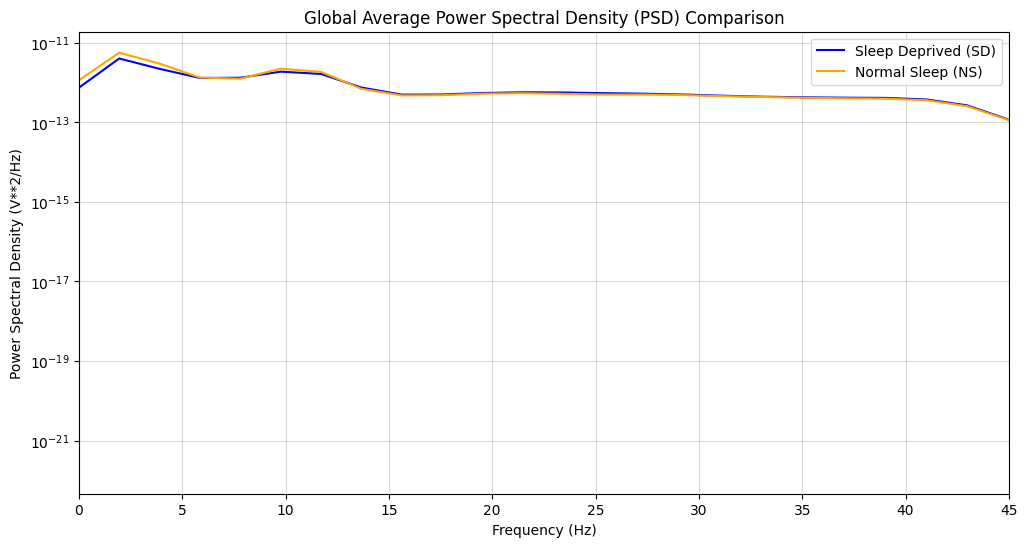

In [27]:
'''freq_SD,psd_SD = signal.welch(np.float16(data_SD), fs=500, axis=-1)
freq_NS,psd_NS = signal.welch(np.float16(data_NS), fs=500, axis=-1)
plt.figure(figsize=(12, 6))
plt.semilogy(freq_SD, np.mean(psd_SD, axis=(0,1)), label='SD', color='blue')
plt.semilogy(freq_NS, np.mean(psd_NS, axis=(0,1)), label='NS', color='orange')
plt.title('Power Spectral Density (PSD) Comparison')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.legend()
plt.show()'''

def get_mean_psd_batched(data, fs=500, batch_size=200):
    """
    Calculates the global average PSD (averaging over all epochs and channels)
    using batch processing to avoid MemoryError.
    """
    total_psd_sum = None
    total_count = 0
    freqs = None
    
    n_epochs = data.shape[0]
    
    # Loop through data in chunks
    for i in range(0, n_epochs, batch_size):
        batch = data[i : i + batch_size]
        
        # Calculate Welch for this small batch
        # Output shape: (Batch_Size, Channels, Frequencies)
        f, psd_batch = signal.welch(batch, fs=fs, axis=-1)
        
        # Sum across Epochs (axis 0) and Channels (axis 1) immediately
        # Result shape: (Frequencies,) -> A single 1D line
        batch_sum = np.sum(psd_batch, axis=(0, 1))
        
        # Accumulate the sum
        if total_psd_sum is None:
            total_psd_sum = batch_sum
            freqs = f
        else:
            total_psd_sum += batch_sum
            
        # Count how many (Epochs * Channels) we have processed
        total_count += batch.shape[0] * batch.shape[1]
    
    # Calculate final mean
    mean_psd = total_psd_sum / total_count
    return freqs, mean_psd

# --- Execution ---
print("Calculating Average PSD for Sleep Deprived (SD)...")
freq_SD, mean_psd_SD = get_mean_psd_batched(data_SD, fs=500)

print("Calculating Average PSD for Normal Sleep (NS)...")
freq_NS, mean_psd_NS = get_mean_psd_batched(data_NS, fs=500)

# --- Plotting ---
plt.figure(figsize=(12, 6))
# Using semilogy for Logarithmic Scale on Y-axis (Standard for PSD)
plt.semilogy(freq_SD, mean_psd_SD, label='Sleep Deprived (SD)', color='blue')
plt.semilogy(freq_NS, mean_psd_NS, label='Normal Sleep (NS)', color='orange')

plt.title('Global Average Power Spectral Density (PSD) Comparison')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V**2/Hz)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlim(0, 45) # Focus on relevant frequencies (Delta to Gamma)
plt.show()

In [28]:
def get_relative_bandpower_batched(data, fs, band_range, batch_size=200):
 
    results = []
    n_epochs = data.shape[0]
    
    # Internal Loop: Handles the batching for you
    for i in range(0, n_epochs, batch_size):
        batch_data = data[i : i + batch_size,:,:]
        
        # 1. Welch (Frequency Domain)
        freqs, psd = signal.welch(batch_data, fs=fs, axis=-1)
        
        # 2. Band Mask
        mask = (freqs >= band_range[0]) & (freqs <= band_range[1])
        total_mask = (freqs >= 0.5) & (freqs <= 40)
        
        # 3. Integrate
        power_channels = np.trapezoid(psd[..., mask], freqs[mask], axis=-1)
        total_power = np.trapz(psd[..., total_mask], freqs[total_mask], axis=-1)
            
        # 4. CRITICAL STEP: Average across Channels -> Shape: (Batch, )
        avg_power = np.mean(power_channels, axis=1)
        avg_total_power = np.mean(total_power, axis=1)
        results.append(avg_power/avg_total_power)
        
    # Combine all batches into one long 1D array
    return np.concatenate(results)

In [29]:
relative_delta_SD = get_relative_bandpower_batched(data_SD, fs=500, band_range=(0.5, 4))
relative_delta_NS = get_relative_bandpower_batched(data_NS, fs=500, band_range=(0.5, 4))
print(f"Delta SD Shape: {relative_delta_SD.shape}")
print(f"Delta NS Shape: {relative_delta_NS.shape}")

C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\1604160827.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd[..., total_mask], freqs[total_mask], axis=-1)


Delta SD Shape: (4915,)
Delta NS Shape: (4915,)


In [30]:
relative_theta_SD = get_relative_bandpower_batched(data_SD, fs=500, band_range=(4, 8))
relative_theta_NS = get_relative_bandpower_batched(data_NS, fs=500, band_range=(4, 8))
print(f"Theta SD Shape: {relative_theta_SD.shape}")
print(f"Theta NS Shape: {relative_theta_NS.shape}")

C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\1604160827.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd[..., total_mask], freqs[total_mask], axis=-1)


Theta SD Shape: (4915,)
Theta NS Shape: (4915,)


In [31]:
relative_alpha_SD = get_relative_bandpower_batched(data_SD, fs=500, band_range=(8, 13))
relative_alpha_NS = get_relative_bandpower_batched(data_NS, fs=500, band_range=(8, 13))
print(f"Alpha SD Shape: {relative_alpha_SD.shape}") 
print(f"Alpha NS Shape: {relative_alpha_NS.shape}")

C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\1604160827.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd[..., total_mask], freqs[total_mask], axis=-1)


Alpha SD Shape: (4915,)
Alpha NS Shape: (4915,)


In [32]:
relative_beta_SD = get_relative_bandpower_batched(data_SD, fs=500, band_range=(13, 30))
relative_beta_NS = get_relative_bandpower_batched(data_NS, fs=500, band_range=(13, 30))
print(f"Beta SD Shape: {relative_beta_SD.shape}")   
print(f"Beta NS Shape: {relative_beta_NS.shape}")

C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\1604160827.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd[..., total_mask], freqs[total_mask], axis=-1)


Beta SD Shape: (4915,)
Beta NS Shape: (4915,)


In [33]:
relative_gamma_SD = get_relative_bandpower_batched(data_SD, fs=500, band_range=(30, 40))
relative_gamma_NS = get_relative_bandpower_batched(data_NS, fs=500, band_range=(30, 40))
print(f"Gamma SD Shape: {relative_gamma_SD.shape}")
print(f"Gamma NS Shape: {relative_gamma_NS.shape}")

C:\Users\suvan\AppData\Local\Temp\ipykernel_15844\1604160827.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = np.trapz(psd[..., total_mask], freqs[total_mask], axis=-1)


Gamma SD Shape: (4915,)
Gamma NS Shape: (4915,)


In [34]:
t_stat_relative_delta, p_relative_delta_t = stats.ttest_ind(relative_delta_SD, relative_delta_NS, equal_var=False)
z_stat_relative_delta, p_relative_delta_z = ztest(relative_delta_SD, relative_delta_NS, value=0)
print("DELTA", t_stat_relative_delta, p_relative_delta_t, z_stat_relative_delta, p_relative_delta_z)

DELTA -7.815815201944916 6.05229227810974e-15 -7.815815201944916 5.460844249464602e-15


In [35]:
t_stat_relative_theta, p_relative_theta_t = stats.ttest_ind(relative_theta_SD, relative_theta_NS, equal_var=False)
z_stat_relative_theta, p_relative_theta_z = ztest(relative_theta_SD, relative_theta_NS, value=0)
print("THETA", t_stat_relative_theta, p_relative_theta_t, z_stat_relative_theta, p_relative_theta_z)

THETA 13.983126632928252 5.634666833708807e-44 13.983126632928249 1.9761205383964297e-44


In [36]:
t_stat_relative_alpha, p_relative_alpha_t = stats.ttest_ind(relative_alpha_SD, relative_alpha_NS, equal_var=False)
z_stat_relative_alpha, p_relative_alpha_z = ztest(relative_alpha_SD, relative_alpha_NS, value=0)
print("ALPHA", t_stat_relative_alpha, p_relative_alpha_t, z_stat_relative_alpha, p_relative_alpha_z)

ALPHA -1.8417856987219916 0.06553699332720529 -1.8417856987219916 0.06550650277889446


In [37]:
t_stat_relative_beta, p_relative_beta_t = stats.ttest_ind(relative_beta_SD, relative_beta_NS, equal_var=False)
z_stat_relative_beta, p_relative_beta_z = ztest(relative_beta_SD, relative_beta_NS, value=0)
print("BETA", t_stat_relative_beta, p_relative_beta_t, z_stat_relative_beta, p_relative_beta_z)

BETA 1.9835007704541814 0.04733934911886143 1.9835007704541814 0.047311521093538846


In [38]:
t_stat_relative_gamma, p_relative_gamma_t = stats.ttest_ind(relative_gamma_SD, relative_gamma_NS, equal_var=False)
z_stat_relative_gamma, p_relative_gamma_z = ztest(relative_gamma_SD, relative_gamma_NS, value=0)
print("GAMMA", t_stat_relative_gamma, p_relative_gamma_t, z_stat_relative_gamma, p_relative_gamma_z)

GAMMA 2.669397187883605 0.0076112501100692 2.669397187883605 0.007598753274788923
